# 01 — EDA: Amazon Product Reviews (Fake Review Detection)

**Dataset**: real Amazon product reviews (McAuley-style export from Kaggle), one row per review, one product per `productASIN`.

Note: this replaces the earlier app-review dataset (`reviewCreatedVersion`/`appVersion` columns), which was reviews of the Amazon mobile app, not of products sold on Amazon.

In [4]:
import pandas as pd

df = pd.read_csv('/content/Review-Guardian/data/raw/reviews.csv', encoding='utf-8')
print(df.shape)
print(df.columns.tolist())
df.head()

(6327, 23)
['s.no', 'helpfulVoteCount', 'images/0', 'images/1', 'images/2', 'images/3', 'images/4', 'images/5', 'images/6', 'images/7', 'productASIN', 'productVariant', 'rating', 'reviewID', 'reviewMetadata', 'reviewPosition', 'reviewText', 'reviewTitle', 'reviewURL', 'verifiedPurchase', 'videos/0', 'cleaned_review_text', 'sentiment_score']


,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,...,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321
3,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",3,This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type...,0.307949
4,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",4,With these three polo shirts I was very satisf...,Pocket Polos Looks Good,https://www.amazon.com/review/RP17IW9ZKENDZ,False,NaN,three polo shirt satisfied quality material go...,0.250000


## Cleaning
- Drop exact duplicate review text
- Drop rows with no text or no rating
- Extract a real datetime from `reviewMetadata` (format: "Reviewed in the United States on <Month DD, YYYY>")
- Fix mojibake in `reviewText` (emoji/punctuation got double-encoded when the CSV was exported)
- Keep `productASIN` as the true product identifier (there is no equivalent of "app version" here — each review belongs to one product)

In [5]:
import re

# Exact duplicates (same review text)
df = df.drop_duplicates(subset=['reviewText'])

# Rows with no text or no rating are useless for classification
df = df.dropna(subset=['reviewText', 'rating'])

# Fix common mojibake from a mis-decoded UTF-8 export (e.g. emoji/punctuation)
def fix_mojibake(t):
    t = str(t)
    try:
        return t.encode('latin1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        return t

df['reviewText'] = df['reviewText'].apply(fix_mojibake)

# Extract the review date out of the free-text reviewMetadata field
def extract_date(meta):
    m = re.search(r'on (.+)$', str(meta))
    return m.group(1) if m else None

df['at'] = pd.to_datetime(df['reviewMetadata'].apply(extract_date), errors='coerce')

# Basic text cleaning (mirrors the previous pipeline, applied to the real review text)
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-z0-9\s.,!?\'"-]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['content_clean'] = df['reviewText'].apply(clean_text)

# Normalize verifiedPurchase to a clean boolean
df['verifiedPurchase'] = df['verifiedPurchase'].astype(str).str.strip().str.lower().map({'true': True, 'false': False})

print(df.shape)
print('Rows with unresolved date:', df['at'].isna().sum())

(6232, 25)
Rows with unresolved date: 0


## Distributions

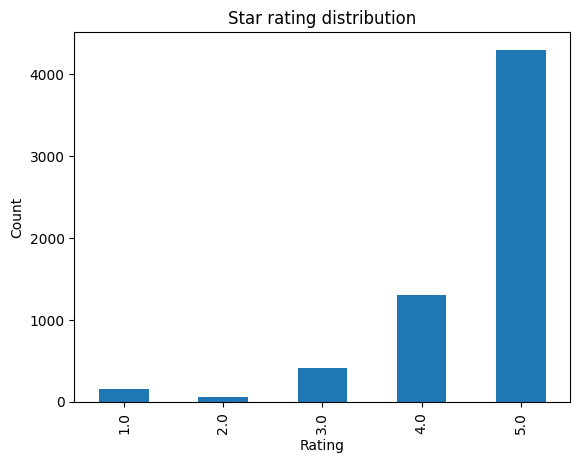

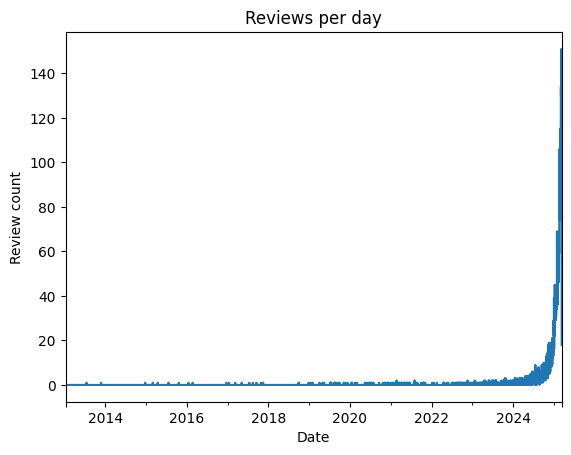

In [6]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar', title='Star rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

df.set_index('at').resample('D').size().plot(title='Reviews per day')
plt.xlabel('Date')
plt.ylabel('Review count')
plt.show()

Number of unique products: 696
count    696.000000
mean       8.954023
std        2.682887
min        1.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       19.000000
Name: count, dtype: float64


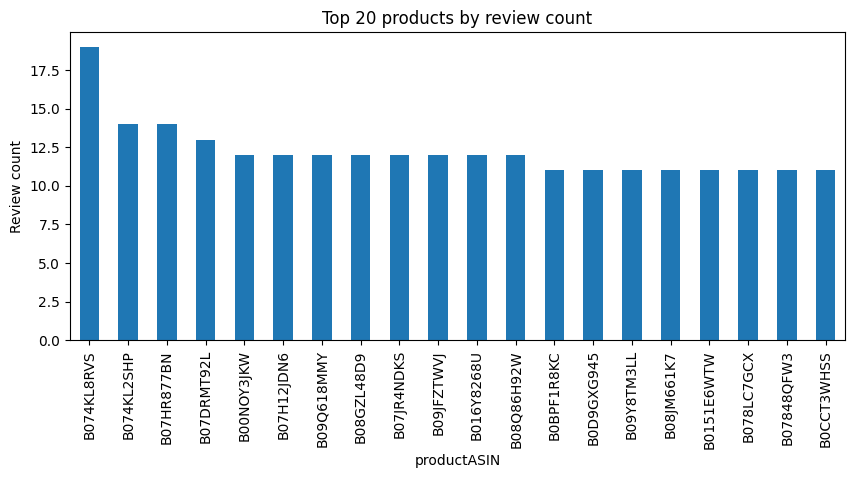

In [7]:
# Product-level view: this is the thing the old dataset couldn't give us at all
reviews_per_product = df['productASIN'].value_counts()
print('Number of unique products:', df['productASIN'].nunique())
print(reviews_per_product.describe())

reviews_per_product.head(20).plot(kind='bar', figsize=(10, 4), title='Top 20 products by review count')
plt.ylabel('Review count')
plt.show()

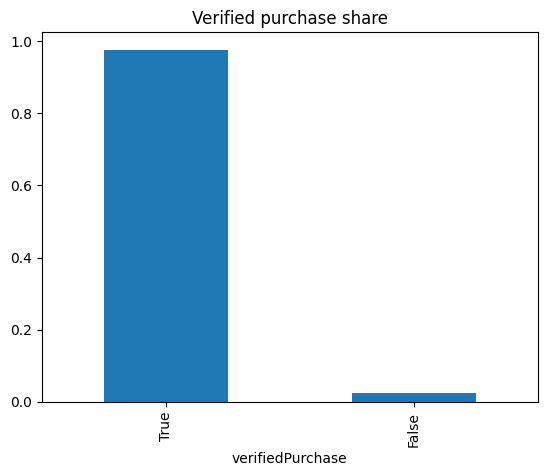

verifiedPurchase
False    4.424837
True     4.532818
Name: rating, dtype: float64


In [8]:
# Verified vs unverified purchase split — a real fake-review signal, unlike anything in the app dataset
df['verifiedPurchase'].value_counts(normalize=True).plot(kind='bar', title='Verified purchase share')
plt.show()

print(df.groupby('verifiedPurchase')['rating'].mean())

## Deliverable

In [9]:
df.to_csv('/content/Review-Guardian/data/processed/cleaned_data.csv', index=False)

In [10]:
import os
print(os.path.exists('/content/Review-Guardian/data/processed/cleaned_data.csv'))

True
